In [39]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
import os
import math

from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()
from qscout.v1.std.noisy import SNLToy1

from jaqalpaq.qsyntax import circuit
from jaqalpaq.generator import generate_jaqal_program
from jaqalpaq.core.algorithm import expand_subcircuits

from qscout.v1.std.noisy import SNLToy1

In [40]:
#Define your Jaqal circuit

jaqal_string = """from Calibration_PulseDefinitions.UserPulses usepulses *

let pi   3.1415926535897
let pi_2 1.57079
let num_gates 2
let ms_angle 1.57079

register q[2]
subcircuit{

loop num_gates{
    //Sy q[1]
    MS q[0] q[1] 0 ms_angle
}

}
"""

In [41]:
# Physical bounds
AMP_IA_MIN,   AMP_IA_MAX   = 0.0,   100.0
ZETA_MIN,     ZETA_MAX     = 0.5,     1.5
FRAMEROT_MIN, FRAMEROT_MAX = -180.0, 180.0

# Gate parameters
NUM_GATES    = 2
MS_ANGLE     = math.pi / 2

# Run emulator on hardware or toy problem 
emulator = True   # set False to run on hardware

In [42]:
def jaqal_objective(u, N: int):
    """
    u[0] → amp_ia   in [0,   100]
    u[1] → zeta     in [0.5, 1.5]
    u[2] → framerot in [-180, 180]

    Returns (Q, sigma) where Q = P(|11⟩) is the fidelity proxy and
    sigma = sqrt(Q*(1-Q)/N) is the binomial noise estimate.
    """
    u = np.asarray(u, dtype=float)

    # Denormalize parameters (need to normalize for surrogate model)
    amp_ia   = AMP_IA_MIN   + (u[0] + 1.0) / 2.0 * (AMP_IA_MAX   - AMP_IA_MIN) #Typically a max of 100, since the amplitude and zeta are intertwined (and diff per qubit), we'll need to think more about how to properly bound this
    zeta     = ZETA_MIN     + (u[1] + 1.0) / 2.0 * (ZETA_MAX     - ZETA_MIN) #blue/red ratio, usually around 1.05
    framerot = FRAMEROT_MIN + (u[2] + 1.0) / 2.0 * (FRAMEROT_MAX - FRAMEROT_MIN) #light shift correction, -180 to 180 degrees

    #Here we're defining a simple error model based on Jaqal's SNLToy1
    delta_theta = (amp_ia*(np.pi/80) - np.pi/2) / 10 #SNLToy1 is silly, it multiples the rotation error by a factor of 10 for all two qubit gates, same for depolarization and phase error
    depolarization = 2e-5+2e-2*(zeta-1.05)**2
    #delta_phi = (framerot + 20) #Couldn't get framerot to act properly in this simple error model
    noisy_model = SNLToy1(2,rotation_error=delta_theta, depolarization = depolarization) #phase_error = delta_phi)

    if emulator:
        
        #Define the override dictionary to change parameters in the jaqal file
        overrides = {
            "ms_angle":    MS_ANGLE,
            "num_gates":   NUM_GATES,
            "__repeats__": N,
        }

        # Emulator version swaps the pulse library
        jaqal_emulator = jaqal_string.replace(
            "from Calibration_PulseDefinitions.UserPulses usepulses *",
            "from qscout.v1.std usepulses *",
        )
        #Run and return results object
        results = run_jaqal_string(jaqal_emulator, backend=noisy_model,
                                   overrides=overrides)
        
        #Extract probabilities from the results object
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])
    else:
        #Define the override dictionary to change parameters in the jaqal file AND the pulse definitions "pd."
        overrides={'pd.amp_ia': amp_ia,
                   'pd.zeta': zeta,
                   'pd.framerot': framerot,
                   'ms_angle': MS_ANGLE,
                   'num_gates': NUM_GATES,
                   '__repeats__': N}
        #Run and return results object
        results = run.run_jaqal_string(jaqal_string, overrides=overrides)
        #Extract probabilities from the results object NOTE: The formatting of the results object is sometimes a little different on the experiment vs. the emulator (extra nesting), so we'll need to confirm the actual object shaping
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])

    # Minimize (1 - probs[-1]) = maximize probs[-1] = P(|11⟩)
    Q     = float(probs[-1])                               
    sigma = math.sqrt(max(Q * (1.0 - Q), 0.0) / N)          # binomial σ

    return Q, sigma

In [43]:
# Load the Julia surrogate model and optimizer
from juliacall import Main as jl
_repo_root = os.getcwd()
jl.seval(f'import Pkg; Pkg.activate("{_repo_root}"; io=devnull)')
jl.seval('Pkg.instantiate(; io=devnull)')
jl.seval(f'include("{os.path.join(_repo_root, "src", "bayes_hetero_opt.jl")}")')

print("Julia BO loaded.")

┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322


Julia BO loaded.


In [ ]:
# Optimization parameters
N_SHOTS         = 200   # shots per evaluation (matches __repeats__ in Jaqal)
N_INIT          = 12    # random initial evaluations before GP is fitted
N_ITER          = 50    # max BO iterations after initialisation
KAPPA           = 1.96   # UCB exploration weight
HYPER_EVERY     = 10    # re-optimise GP hyperparameters every N iterations
N_RESTARTS      = 5     # random restarts for hyperparameter optimisation
FIDELITY_THRESH = None  # early-stop when measured Q ≥ threshold, e.g. 0.98

# Normalised bounds [-1, 1]^3 passed to Julia
bounds    = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]
jl_bounds = jl.seval("Vector{Tuple{Float64,Float64}}")([tuple(b) for b in bounds])

In [45]:
# Run Julia BO optimization
# The jaqal_objective is called within Julia
jl.seval("""
function _run_bo(f, bounds, n_shots, n_init, n_iter, kap, seed_val,
                 hyper_every, n_restarts, fid_thresh)
    bayesopt_ucb_threshold(f;
        bounds=bounds,
        n_shots=n_shots,
        n_init=n_init,
        n_iter=n_iter,
        κ=kap,
        seed=seed_val,
        maximize=true,
        fidelity_threshold=fid_thresh,
        hyper_every=hyper_every,
        learn_noise_scale=true,
        n_restarts=n_restarts,
    )
end
""")

fid_julia = jl.nothing if FIDELITY_THRESH is None else float(FIDELITY_THRESH)

start_time = time.time()
result = jl._run_bo(
    jaqal_objective,
    jl_bounds,
    N_SHOTS, N_INIT, N_ITER,
    float(KAPPA),
    42,
    HYPER_EVERY, N_RESTARTS,
    fid_julia,
)
elapsed_time = time.time() - start_time
print(f"BO completed in {elapsed_time:.2f} seconds.")

BO completed in 9.94 seconds.


In [46]:
# Julia results
u_last     = np.array(result.x_last)
amp_last   = AMP_IA_MIN   + (u_last[0] + 1.0) / 2.0 * (AMP_IA_MAX   - AMP_IA_MIN)
zeta_last  = ZETA_MIN     + (u_last[1] + 1.0) / 2.0 * (ZETA_MAX     - ZETA_MIN)
frame_last = FRAMEROT_MIN + (u_last[2] + 1.0) / 2.0 * (FRAMEROT_MAX - FRAMEROT_MIN)

print(f"Recommended amp_ia    = {amp_last:.4f}")
print(f"Recommended zeta      = {zeta_last:.6f}")
print(f"Recommended framerot  = {frame_last:.4f}")
print(f"Measured Q at x_last  = {float(result.y_last):.6f}")
print(f"GP mean at x_last     = {float(result.y_hat_last):.6f}")
print(f"Iterations used       = {result.n_iter_actual}")
print(f"Total shots           = {result.total_shots}")
print(f"Acq points            = {len(result.i_acq)}  (indices: init + UCB queries)")
print(f"Opt points            = {len(result.i_opt)}  (indices: GPR recommendation evals)")

Recommended amp_ia    = 39.9314
Recommended zeta      = 1.038537
Recommended framerot  = -61.3703
Measured Q at x_last  = 0.999427
GP mean at x_last     = 0.999766
Iterations used       = 50
Total shots           = 12600
Acq points            = 62  (indices: init + UCB queries)
Opt points            = 1  (indices: GPR recommendation evals)


In [47]:
import scipy.optimize as opt

nm_amp_trace   = []
nm_zeta_trace  = []
nm_non11_trace = []

def _nm_objective(params):
    amp_ia, zeta, framerot = params
    u = [
        2.0 * (amp_ia   - AMP_IA_MIN)   / (AMP_IA_MAX   - AMP_IA_MIN)   - 1.0,
        2.0 * (zeta     - ZETA_MIN)     / (ZETA_MAX     - ZETA_MIN)     - 1.0,
        2.0 * (framerot - FRAMEROT_MIN) / (FRAMEROT_MAX - FRAMEROT_MIN) - 1.0,
    ]
    Q, _ = jaqal_objective(u, N_SHOTS)
    nm_amp_trace.append(amp_ia)
    nm_zeta_trace.append(zeta)
    nm_non11_trace.append(1.0 - Q)
    return 1.0 - Q

nm_start = time.time()
nm_result = opt.minimize(
    fun=_nm_objective,
    x0=(25.0, 0.87, 0.0),
    bounds=[(AMP_IA_MIN, AMP_IA_MAX), (ZETA_MIN, ZETA_MAX), (FRAMEROT_MIN, FRAMEROT_MAX)],
    tol=0.01,
    method='Nelder-Mead',
    options={'maxiter': N_ITER},
)
nm_elapsed = time.time() - nm_start

print(f"Nelder-Mead completed in {nm_elapsed:.2f} s ({len(nm_non11_trace)} evaluations)")
print(f"Best amp_ia   = {nm_result.x[0]:.4f}")
print(f"Best zeta     = {nm_result.x[1]:.6f}")
print(f"Best framerot = {nm_result.x[2]:.4f}")
print(f"Best Q        = {1.0 - nm_result.fun:.6f}")

Nelder-Mead completed in 1.01 s (71 evaluations)
Best amp_ia   = 39.9977
Best zeta     = 1.050174
Best framerot = -0.0011
Best Q        = 0.999500


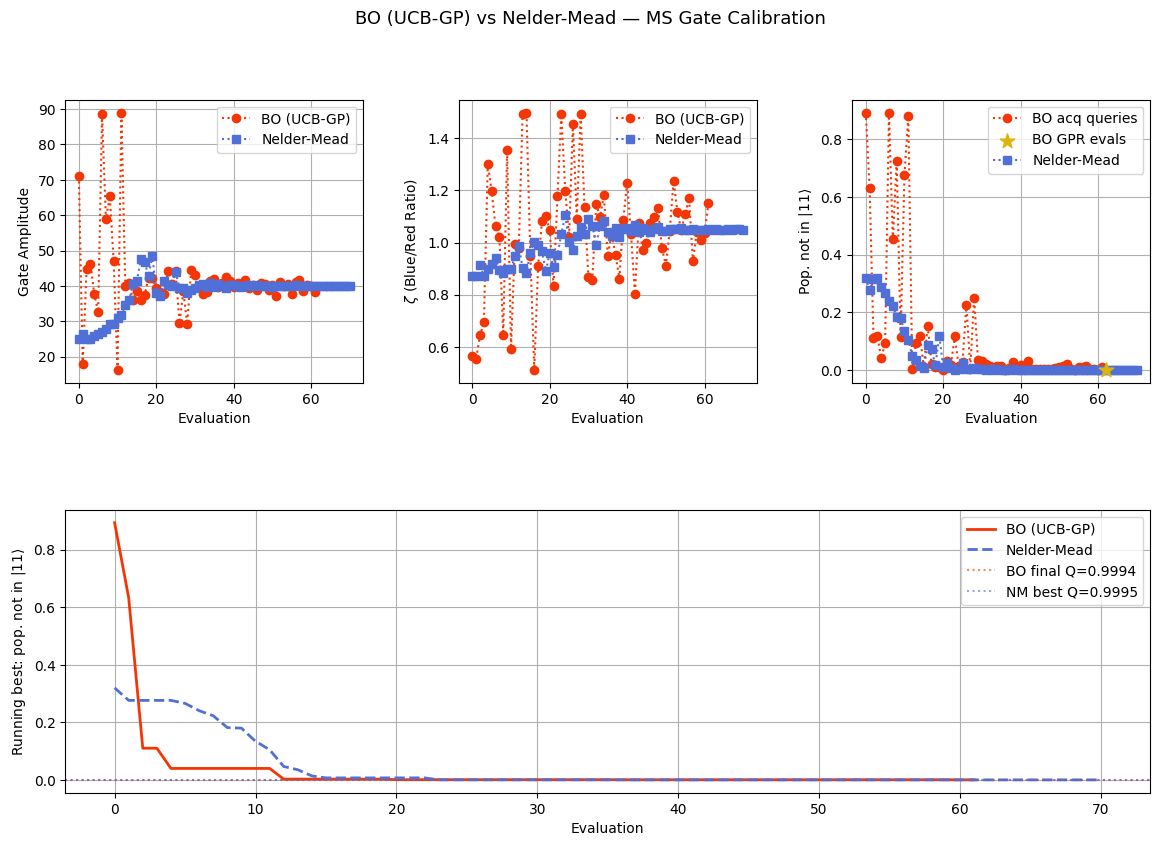

In [48]:
# BO traces
i_acq = [int(i) - 1 for i in result.i_acq]
i_opt  = [int(i) - 1 for i in result.i_opt]
X_all  = np.array(result.X).T
y_all  = np.array(result.y)

X_acq = X_all[i_acq];  y_acq = y_all[i_acq]
X_opt = X_all[i_opt];  y_opt = y_all[i_opt]

bo_amp_trace   = [AMP_IA_MIN + (u[0]+1)/2*(AMP_IA_MAX-AMP_IA_MIN) for u in X_acq]
bo_zeta_trace  = [ZETA_MIN   + (u[1]+1)/2*(ZETA_MAX-ZETA_MIN)      for u in X_acq]
bo_non11_trace = [1.0 - q for q in y_acq]

# Layout: trajectory row + convergence row
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])    # full-width convergence plot

bo_kw = dict(linestyle=':', marker='o', color='xkcd:orangish red')
nm_kw = dict(linestyle=':', marker='s', color='xkcd:cornflower blue')

# Gate amplitude trajectory
ax1.plot(range(len(bo_amp_trace)), bo_amp_trace, **bo_kw, label='BO (UCB-GP)')
ax1.plot(range(len(nm_amp_trace)), nm_amp_trace, **nm_kw, label='Nelder-Mead')
ax1.set_xlabel('Evaluation'); ax1.set_ylabel('Gate Amplitude'); ax1.grid(); ax1.legend()

# Zeta trajectory
ax2.plot(range(len(bo_zeta_trace)), bo_zeta_trace, **bo_kw, label='BO (UCB-GP)')
ax2.plot(range(len(nm_zeta_trace)), nm_zeta_trace, **nm_kw, label='Nelder-Mead')
ax2.set_xlabel('Evaluation'); ax2.set_ylabel(r'$\zeta$ (Blue/Red Ratio)'); ax2.grid(); ax2.legend()

# Non-|11⟩ population trajectory 
ax3.plot(range(len(bo_non11_trace)), bo_non11_trace, **bo_kw, label='BO acq queries')
if len(y_opt) > 0:
    ax3.scatter(range(len(bo_non11_trace), len(bo_non11_trace) + len(y_opt)),
                [1.0 - q for q in y_opt], marker='*', s=120,
                color='xkcd:gold', zorder=5, label='BO GPR evals')
ax3.plot(range(len(nm_non11_trace)), nm_non11_trace, **nm_kw, label='Nelder-Mead')
ax3.set_xlabel('Evaluation'); ax3.set_ylabel(r'Pop. not in $|11\rangle$'); ax3.grid(); ax3.legend()

# Running best (convergence) 
bo_best = np.minimum.accumulate(bo_non11_trace)
nm_best = np.minimum.accumulate(nm_non11_trace)
ax4.plot(range(len(bo_best)), bo_best, color='xkcd:orangish red', linewidth=2, label='BO (UCB-GP)')
ax4.plot(range(len(nm_best)), nm_best, color='xkcd:cornflower blue', linewidth=2,
         linestyle='--', label='Nelder-Mead')
ax4.axhline(float(1.0 - result.y_last), color='xkcd:orangish red', linestyle=':',
            alpha=0.6, label=f'BO final Q={result.y_last:.4f}')
ax4.axhline(nm_result.fun, color='xkcd:cornflower blue', linestyle=':',
            alpha=0.6, label=f'NM best Q={1-nm_result.fun:.4f}')
ax4.set_xlabel('Evaluation'); ax4.set_ylabel(r'Running best: pop. not in $|11\rangle$')
ax4.grid(); ax4.legend()

plt.suptitle('BO (UCB-GP) vs Nelder-Mead — MS Gate Calibration', fontsize=13)
plt.show()